# 1. 3D Triangulation

In [10]:
import cv2
import numpy as np

P1 = np.eye(3, 4, dtype=np.float32)
P2 = np.eye(3, 4, dtype=np.float32)
P2[0, 3] = -1

N = 5
points3d = np.empty((4, N), np.float32)
points3d[:3, :] = np.random.randn(3, N)
points3d[3, :] = 1

points1 = P1 @ points3d
points1 = points1[:2, :] / points1[2, :]
points1[:2, :] += np.random.randn(2, N) * 1e-2

points2 = P2 @ points3d
points2 = points2[:2, :] / points2[2, :]
points2[:2, :] += np.random.randn(2, N) * 1e-2

points3d_reconstr = cv2.triangulatePoints(P1, P2, points1, points2)
points3d_reconstr /= points3d_reconstr[3, :]

print('Original points')
print(points3d[:3].T)
print('Reconstructed points')
print(points3d_reconstr[:3].T)

Original points
[[ 0.29088613  0.9113901   1.0545809 ]
 [-0.5764727   0.6873547  -1.0681665 ]
 [ 1.018707    0.7044283   0.40152353]
 [ 2.5993571  -0.44167876  0.6982204 ]
 [-0.2833217   0.5930719   2.1685407 ]]
Reconstructed points
[[ 0.2914269   0.9122311   1.0482746 ]
 [-0.57927746  0.69019157 -1.0726187 ]
 [ 1.0158687   0.7037299   0.40025052]
 [ 2.5974004  -0.44228885  0.6985761 ]
 [-0.27677497  0.57317984  2.1352074 ]]


# 2. Find relative camera-object pose using PnP algorithm

In [11]:
import cv2
import numpy as np

camera_matrix = np.load('./camera_mat.npy')
dist_coefs = np.load('./dist_coefs.npy')
img = cv2.imread('./img_00.png')

pattern_size = (10, 7)
res, corners = cv2.findChessboardCorners(img, pattern_size)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-3)
corners = cv2.cornerSubPix(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY),
                           corners, (10, 10), (-1, -1), criteria)

pattern_points = np.zeros((np.prod(pattern_size), 3), np.float32)
pattern_points[:, :2] = np.indices(pattern_size).T.reshape(-1, 2)

ret, rvec, tvec = cv2.solvePnP(pattern_points, corners, camera_matrix, dist_coefs,
                                None, None, False, cv2.SOLVEPNP_ITERATIVE)

img_points, _ = cv2.projectPoints(pattern_points, rvec, tvec, camera_matrix, dist_coefs)

for c in img_points.squeeze():
    cv2.circle(img, tuple(c.astype(int)), 10, (0, 255, 0), 2)

cv2.imshow('points', img)
cv2.waitKey()

cv2.destroyAllWindows()

# 3. Stereo rectification

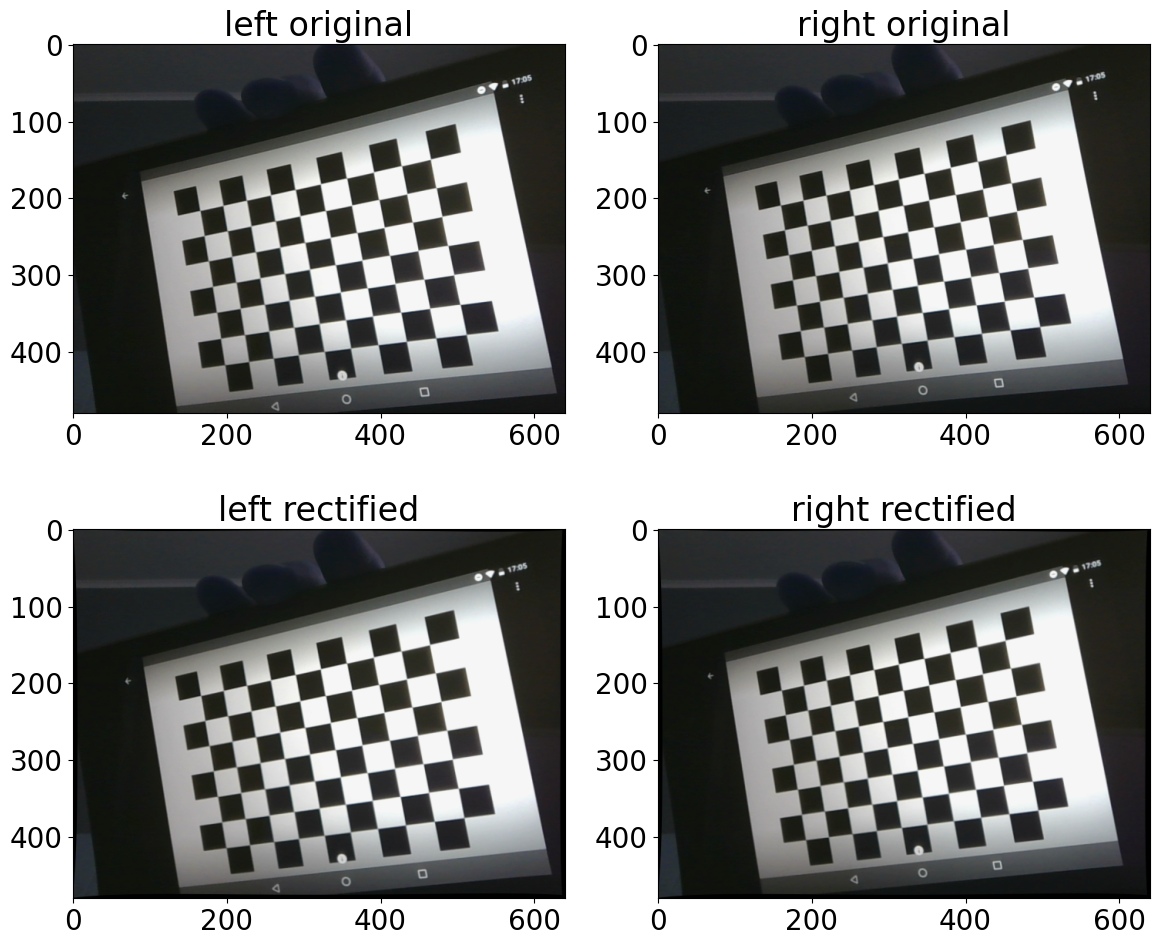

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 20})

Kl = np.load('./camera_mat.npy')
Dl = np.load('./dist_coefs.npy')
Kr = Kl.copy()
Dr = Dl.copy()

left_img = cv2.imread('./img_00.png')
right_img = cv2.imread('./img_01.png')
img_size = (left_img.shape[1], left_img.shape[0])

R = np.eye(3, dtype=np.float64)
T = np.array([[-1.0], [0.0], [0.0]])

R1, R2, P1, P2, Q, validRoi1, validRoi2 = cv2.stereoRectify(Kl, Dl, Kr, Dr, img_size, R, T)

xmap1, ymap1 = cv2.initUndistortRectifyMap(Kl, Dl, R1, Kl, img_size, cv2.CV_32FC1)
xmap2, ymap2 = cv2.initUndistortRectifyMap(Kr, Dr, R2, Kr, img_size, cv2.CV_32FC1)

left_img_rectified = cv2.remap(left_img, xmap1, ymap1, cv2.INTER_LINEAR)
right_img_rectified = cv2.remap(right_img, xmap2, ymap2, cv2.INTER_LINEAR)

plt.figure(0, figsize=(12, 10))
plt.subplot(221)
plt.title('left original')
plt.imshow(left_img, cmap='gray')
plt.subplot(222)
plt.title('right original')
plt.imshow(right_img, cmap='gray')
plt.subplot(223)
plt.title('left rectified')
plt.imshow(left_img_rectified, cmap='gray')
plt.subplot(224)
plt.title('right rectified')
plt.imshow(right_img_rectified, cmap='gray')
plt.tight_layout()
plt.show()

# 4. Fundamental matrix computation

In [13]:
import cv2
import numpy as np

Kl = np.load('./camera_mat.npy')
Dl = np.load('./dist_coefs.npy')
Kr = Kl.copy()
Dr = Dl.copy()

left_img = cv2.imread('./img_00.png', cv2.IMREAD_GRAYSCALE)
right_img = cv2.imread('./img_01.png', cv2.IMREAD_GRAYSCALE)

pattern_size = (10, 7)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-3)

res1, corners1 = cv2.findChessboardCorners(left_img, pattern_size)
corners1 = cv2.cornerSubPix(left_img, corners1, (10, 10), (-1, -1), criteria)

res2, corners2 = cv2.findChessboardCorners(right_img, pattern_size)
corners2 = cv2.cornerSubPix(right_img, corners2, (10, 10), (-1, -1), criteria)

left_pts = cv2.undistortPoints(corners1, Kl, Dl, P=Kl)
right_pts = cv2.undistortPoints(corners2, Kr, Dr, P=Kr)

F, mask = cv2.findFundamentalMat(left_pts, right_pts, cv2.FM_LMEDS)

E = Kr.T @ F @ Kl

print('Fundamental matrix:')
print(F)
print('Essential matrix:')
print(E)

Fundamental matrix:
[[ 2.57123117e-08  8.21407874e-04 -8.37381532e-02]
 [-8.16207607e-04  3.20159261e-06  3.44722116e-01]
 [ 7.91949313e-02 -3.38260089e-01  1.00000000e+00]]
Essential matrix:
[[ 9.68212027e-03  3.08972043e+02  6.70752283e+01]
 [-3.07015966e+02  1.20297712e+00  4.60814272e+01]
 [-6.91027568e+01 -4.01422982e+01  1.59842351e+00]]


# 5. Essential decomposition into rotation and translation

In [14]:
import cv2
import numpy as np

Kl = np.load('./camera_mat.npy')
Dl = np.load('./dist_coefs.npy')
Kr = Kl.copy()
Dr = Dl.copy()

left_img = cv2.imread('./img_00.png', cv2.IMREAD_GRAYSCALE)
right_img = cv2.imread('./img_01.png', cv2.IMREAD_GRAYSCALE)

pattern_size = (10, 7)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-3)

res1, corners1 = cv2.findChessboardCorners(left_img, pattern_size)
corners1 = cv2.cornerSubPix(left_img, corners1, (10, 10), (-1, -1), criteria)

res2, corners2 = cv2.findChessboardCorners(right_img, pattern_size)
corners2 = cv2.cornerSubPix(right_img, corners2, (10, 10), (-1, -1), criteria)

left_pts = cv2.undistortPoints(corners1, Kl, Dl, P=Kl)
right_pts = cv2.undistortPoints(corners2, Kr, Dr, P=Kr)

F, mask = cv2.findFundamentalMat(left_pts, right_pts, cv2.FM_LMEDS)
E = Kr.T @ F @ Kl

R1, R2, T = cv2.decomposeEssentialMat(E)

print('Rotation 1:')
print(R1)
print('Rotation 2:')
print(R2)
print('Translation:')
print(T)

Rotation 1:
[[-0.96329817 -0.05366401  0.26301484]
 [-0.06220584 -0.90851397 -0.41319826]
 [ 0.26112653 -0.41439419  0.87183163]]
Rotation 2:
[[ 9.99834084e-01  5.17393590e-04 -1.82081317e-02]
 [-6.64223250e-04  9.99967306e-01 -8.05883724e-03]
 [ 1.82033668e-02  8.06959441e-03  9.99801740e-01]]
Translation:
[[ 0.12657978]
 [-0.21781523]
 [ 0.96774691]]


# 6. Estimating disparity map for stereo images

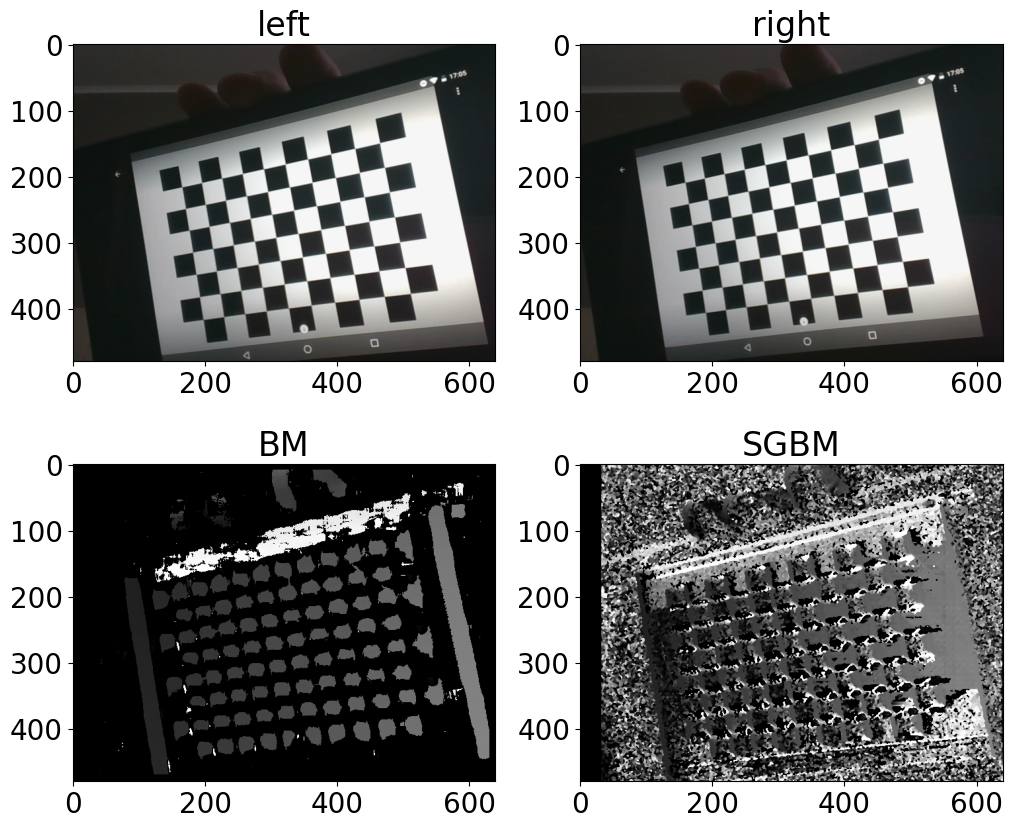

In [15]:
import cv2
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 20})

left_img = cv2.imread('./img_00.png')
right_img = cv2.imread('./img_01.png')

stereo_bm = cv2.StereoBM_create(32)
dispmap_bm = stereo_bm.compute(cv2.cvtColor(left_img, cv2.COLOR_BGR2GRAY),
                               cv2.cvtColor(right_img, cv2.COLOR_BGR2GRAY))

stereo_sgbm = cv2.StereoSGBM_create(0, 32)
dispmap_sgbm = stereo_sgbm.compute(left_img, right_img)

plt.figure(figsize=(12, 10))
plt.subplot(221)
plt.title('left')
plt.imshow(left_img[:, :, [2, 1, 0]])
plt.subplot(222)
plt.title('right')
plt.imshow(right_img[:, :, [2, 1, 0]])
plt.subplot(223)
plt.title('BM')
plt.imshow(dispmap_bm, cmap='gray')
plt.subplot(224)
plt.title('SGBM')
plt.imshow(dispmap_sgbm, cmap='gray')
plt.show()